# Operational Ticket Analytics – Public Sector Case Study

This project was developed as part of a real-world collaboration with a public sector digital services organization in Tierra del Fuego, Argentina.

The objective was to analyze operational performance within a citizen ticket management system, focusing on response times, resolution efficiency, backlog behavior and operational patterns across categories, agents and cities.

The analysis combined exploratory data analysis (EDA), KPI generation, operational analytics and basic natural language processing (NLP) techniques applied to ticket metadata and internal notes.

Due to privacy and confidentiality considerations, the original datasets are not publicly available. This repository only includes anonymized methodology, aggregated indicators and selected visualizations.

**INDICE**
1. Project Overview
2. Data Privacy & Anonymization
3. Data Loading
4. Data Preparation
5. KPI Summary
6. Operational Analysis
   6.1 Tickets by category
   6.2 Resolution time
   6.3 Backlog analysis
   6.4 Monthly evolution
7. Focus Case: Haberes
8. Focus Case: SUNA & GEN
9. Key Insights
10. Business Recommendations
11. Next Steps

#**1. Project Overview**

The project focused on analyzing the operational behavior of a public ticket management system used to process citizen requests and administrative incidents.

The analysis aimed to:

- Measure operational efficiency through KPIs
- Evaluate response and resolution times
- Detect backlog accumulation patterns
- Identify operational bottlenecks
- Compare workload distribution across categories and agents
- Explore behavioral patterns in internal ticket notes using NLP techniques

The workflow combined data cleaning, exploratory data analysis (EDA), operational analytics and text analysis techniques using Python.

#**2. Data Privacy & Anonymization**


The original datasets contained sensitive operational and personal information related to citizens, internal agents and administrative processes.

To preserve confidentiality:

- Personal identifiers were removed
- Internal notes were anonymized
- Sensitive ticket content was excluded
- Visualizations only display aggregated information
- Example outputs were simplified for portfolio purposes

This repository focuses on methodology, operational insights and analytical workflow rather than exposing raw institutional data.

#**3. Data Loading**

The project was based on multiple JSON exports extracted from the ticket management platform.

The datasets included:

- Tickets metadata
- Categories information
- Internal notes
- Users and agents information
- Customer-related data

The data was loaded and consolidated into analytical tables for further operational analysis.

In [13]:
import json
import pandas as pd
import numpy as np

In [12]:
import os

os.makedirs("data", exist_ok=True)

print("Folder created successfully")


Folder created successfully


In [14]:
def load_export_json(path):
    with open(path, "r", encoding="utf-8") as f:
        obj = json.load(f)

    key = list(obj.keys())[0]
    return pd.DataFrame(obj[key])


In [15]:
tickets = load_export_json("data/tickets.json")
categories = load_export_json("data/categories.json")
customers = load_export_json("data/customers.json")
users = load_export_json("data/users.json")
notes = load_export_json("data/notes.json")

In [16]:
datasets = {
    "tickets": tickets.shape,
    "categories": categories.shape,
    "users": users.shape,
    "notes": notes.shape,
    "customers": customers.shape
}

datasets

{'tickets': (40869, 153),
 'categories': (17, 9),
 'users': (157, 34),
 'notes': (1804, 6),
 'customers': (8570, 10)}

#**4. Data Preparation**

The raw JSON exports required multiple preprocessing and standardization steps before the operational analysis could be performed.

The preparation workflow included:

- Data validation
- Handling missing values
- Standardization of variable names
- Date transformation and duration calculations
- Creation of analytical indicators
- Consolidation into an analytical table

In [17]:
tickets.shape

(40869, 153)

In [18]:
tickets.head(3)

,id,trackid,u_name,u_email,category,priority,subject,message,message_html,dt,...,MovInt_Suna,CUISE_Suna,dt_date,Prioridad,Estado,CategoriaName,AsignadoA_User,AsignadoA_Name,AsignadoPor_User,AsignadoPor_Name
0,6,JX2-VPQ-BREG,[Cliente],barrientos@aif.gob.ar,5,2,solicitud de correo electrónico,"Buenos días, solicito correo electrónico de la...","Buenos días, solicito correo electrónico de la...",2024-03-27 11:16:02,...,,,2024-03-27,Media,Resuelto,Soporte Tecnico,None,None,None,None
1,7,3QM-6YB-8QX1,Viviana Morales,vimorales@aif.gob.ar,4,3,prueba,olvide mi clave,olvide mi clave,2024-03-27 15:19:15,...,,,2024-03-27,Baja,Resuelto,Infraestructura Operaciones,None,None,None,None
2,8,QV6-9Z8-D47W,Viviana Morales,vimorales@aif.gob.ar,1,2,prueba,hola<br />\n<br />\n-- <br />\n cid:part1.GfO4...,hola<br />\n<br />\n-- <br />\n cid:part1.GfO4...,2024-03-27 15:36:01,...,,,2024-03-27,Media,Resuelto,Mesa de Ayuda AIF,None,None,None,None


In [19]:
# Main columns from ticket dataset

tickets.columns.tolist()[:20]

['id',
 'trackid',
 'u_name',
 'u_email',
 'category',
 'priority',
 'subject',
 'message',
 'message_html',
 'dt',
 'lastchange',
 'firstreply',
 'closedat',
 'articles',
 'ip',
 'language',
 'status',
 'openedby',
 'firstreplyby',
 'closedby']

In [20]:
# Missing values overview

missing_values = (
    tickets.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_values.head(10)

,0
language,40869
articles,40869
eid,40869
satisfaction_email_dt,40869
due_date,40869
AsignadoPor_Name,15711
AsignadoPor_User,15711
assignedby,8527
AsignadoA_Name,5663
AsignadoA_User,5663


The ticket dataset presented missing values mainly in optional operational fields. Critical variables related to ticket status, timestamps and categories showed acceptable completeness for operational analysis.

In [21]:
# Date conversion

tickets["dt"] = pd.to_datetime(tickets["dt"], errors="coerce")
tickets["firstreply"] = pd.to_datetime(tickets["firstreply"], errors="coerce")
tickets["closedat"] = pd.to_datetime(tickets["closedat"], errors="coerce")

In [22]:
# Resolution time in hours

tickets["resolution_hours"] = (
    tickets["closedat"] - tickets["dt"]
).dt.total_seconds() / 3600

Operational duration metrics were calculated to evaluate response and resolution efficiency across categories, agents and operational units.

#**5. KPI Summary**

This section summarizes the main operational indicators extracted from the ticket management system.

The KPIs provide a high-level overview of ticket volume, operational efficiency, response performance and backlog behavior during the analyzed period.

These indicators were used as a starting point to evaluate the overall performance of the system before moving into more detailed analysis by category, agent and city.

In [24]:
# General operational KPIs

kpis = pd.DataFrame({
    "Metric": [
        "Total Tickets",
        "Closed Tickets",
        "Open Tickets",
        "Resolution Rate (%)",
        "Median Resolution Time (hours)",
        "Median First Response Time (hours)"
    ],
    "Value": [
        f"{total_tickets:,}",
        f"{closed_tickets:,}",
        f"{open_tickets:,}",
        round(resolution_rate, 2),
        round(median_resolution_hours, 2),
        round(median_first_response_hours, 2)
    ]
})

kpis

,Metric,Value
0,Total Tickets,"40,869"
1,Closed Tickets,"39,339"
2,Open Tickets,"1,530"
3,Resolution Rate (%),96.26
4,Median Resolution Time (hours),24.23
5,Median First Response Time (hours),10.94


### Key Findings

The system processed more than 40,000 tickets during the analyzed period, with a high overall resolution rate of 96.28%.

Median resolution time was approximately 24 hours, while median first response time was under 11 hours, suggesting relatively strong operational responsiveness across the ticket management workflow.

Although the majority of tickets were resolved, the remaining backlog of open cases highlights opportunities for deeper analysis across categories, operational units and assigned agents.

#**6. Operational Analysis**

**6.1 Tickets by category**

This section explores the operational distribution of tickets across service categories.

Understanding ticket volume by category helps identify the most demanded service areas and provides context for evaluating operational workload and performance.

In [25]:
# Top categories by ticket volume

category_volume = (
    tickets["CategoriaName"]
    .value_counts()
    .head(10)
    .sort_values(ascending=True)
)

category_volume

,count
CategoriaName,
Medicina Laboral,358
Analisis y Desarrollo de Sistemas,402
Empresa//SUNA,564
Implementacion GENRRHH GTF,663
SUNA//ADMINISTRACIÓN D.G. PERSONAL,685
Implementacion de Sistemas,713
Haberes,1805
Soporte Tecnico,2468
Sistema SUNA (Ministerio de Educación),8371


In [26]:
import matplotlib.pyplot as plt

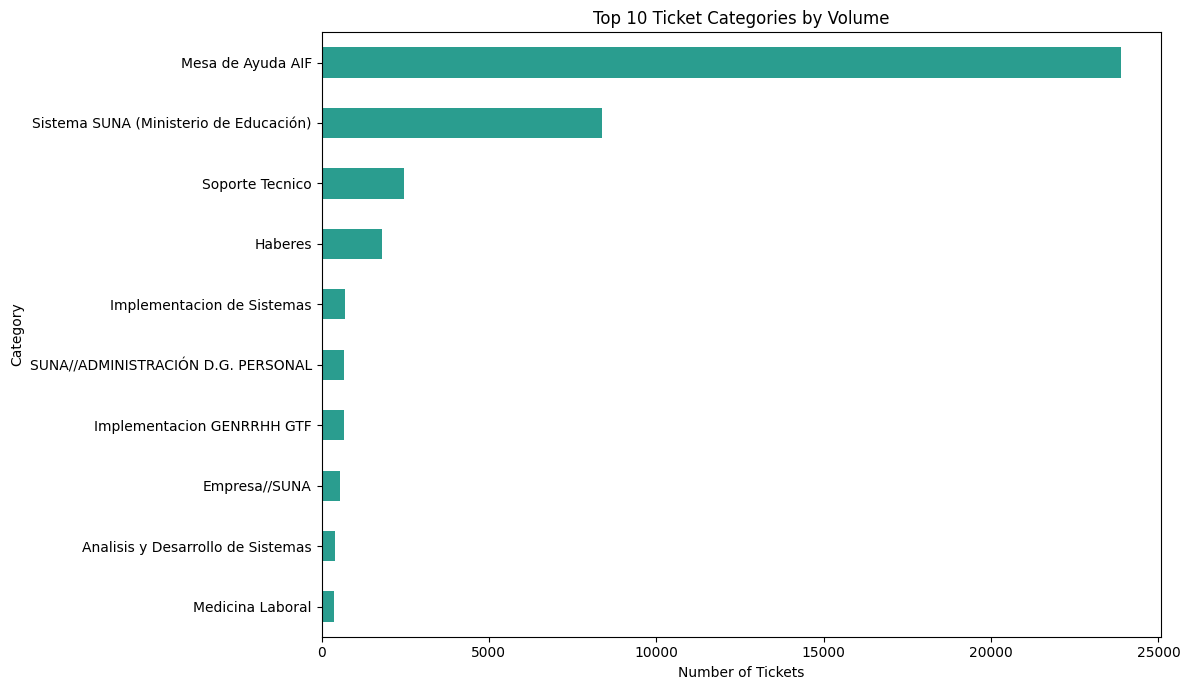

In [44]:
# Bar chart - Top 10 categories by ticket volume

plt.figure(figsize=(12,7))

category_volume.plot(
    kind="barh",
    color="#2A9D8F"
)

plt.xlabel("Number of Tickets")
plt.ylabel("Category")
plt.title("Top 10 Ticket Categories by Volume")

plt.tight_layout()
plt.show()

### Key Insight

Ticket demand was highly concentrated in a small number of service categories.

Mesa de Ayuda AIF represented the largest operational volume by a significant margin, followed by Sistema SUNA. This concentration suggests that a limited number of categories generated most of the workload within the ticket management system.

Although Haberes represented a smaller share of total volume, it was selected for deeper analysis due to its operational relevance and stakeholder interest during the project.

**6.2 Resolution time**

This analysis explores the distribution of ticket resolution times across the system.

Resolution time was measured as the elapsed time between ticket creation and closure, expressed in hours.

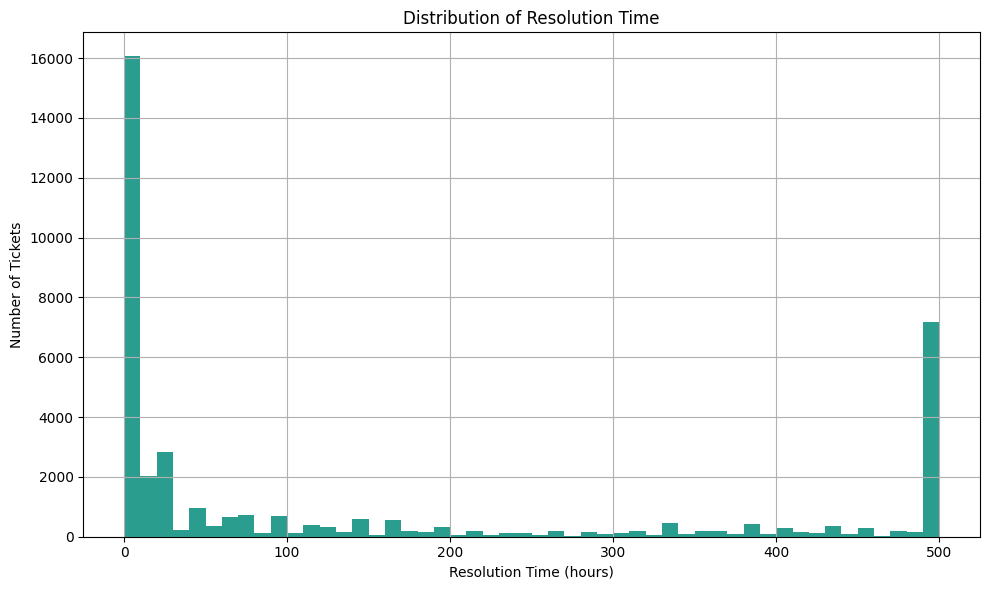

In [45]:
# Distribution of resolution time

plt.figure(figsize=(10,6))

tickets["resolution_hours"].dropna().clip(upper=500).hist(
    bins=50,
    color="#2A9D8F"
)

plt.xlabel("Resolution Time (hours)")
plt.ylabel("Number of Tickets")
plt.title("Distribution of Resolution Time")

plt.tight_layout()
plt.show()

### Key Insight

The resolution time distribution showed a strongly right-skewed pattern.

Most tickets were resolved within a short time window after creation, suggesting a high volume of operational requests with relatively fast turnaround times.

At the same time, the presence of a long tail of delayed cases indicates that a subset of tickets remained unresolved for significantly longer periods.

This pattern suggests the coexistence of:

- high-volume routine tickets resolved quickly
- more complex or delayed operational cases requiring extended resolution time

**6.3 Backlog analysis**

This section evaluates backlog behavior by identifying tickets that remained open at the time of data extraction.

Backlog analysis helps estimate pending operational workload and detect areas where requests accumulate over time without resolution.

In [31]:
# Open tickets backlog

backlog_by_category = (
    tickets[tickets["closedat"].isna()]
    ["CategoriaName"]
    .value_counts()
    .head(10)
    .sort_values(ascending=True)
)

backlog_by_category

,count
CategoriaName,
Infraestructura Operaciones,19
Mesa de Ayuda AIF,57
SUNA//ADMINISTRACIÓN D.G. RRHH,73
Haberes,77
Implementacion GENRRHH GTF,84
Implementacion de Sistemas,86
Medicina Laboral,152
Sistema SUNA (Ministerio de Educación),153
Empresa//SUNA,196


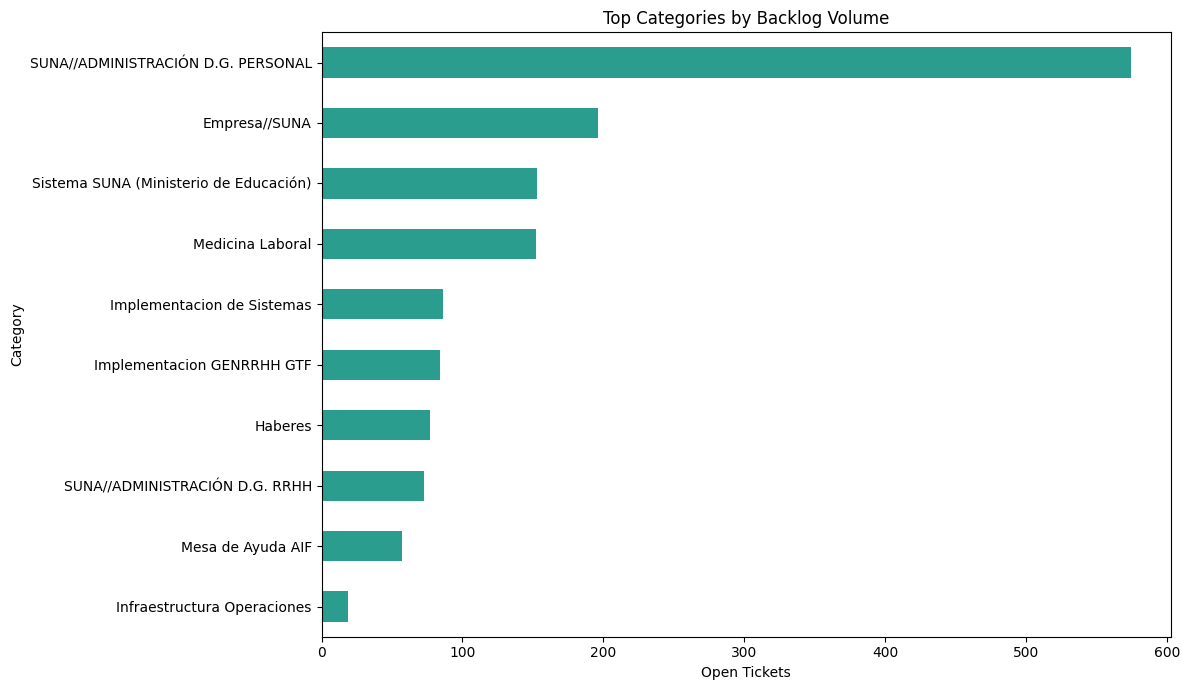

In [46]:
plt.figure(figsize=(12,7))

backlog_by_category.plot(
    kind="barh",
    color="#2A9D8F"
)

plt.xlabel("Open Tickets")
plt.ylabel("Category")
plt.title("Top Categories by Backlog Volume")

plt.tight_layout()
plt.show()

### Key Insight

The backlog distribution shows that unresolved tickets were concentrated in a small number of operational categories.

The category **SUNA/ADMINISTRACIÓN D.G. PERSONAL** represented the largest backlog volume by a significant margin, indicating a high concentration of pending workload compared with the rest of the system.

This suggests that although some categories may not generate the highest ticket demand overall, they can still accumulate unresolved cases over time and become operational bottlenecks.

Categories such as **Empresa/SUNA**, **Sistema SUNA**, and **Medicina Laboral** also showed relevant backlog levels, while **Haberes** appeared with a lower but still visible number of open cases.

Comparing ticket demand versus backlog volume helps distinguish between:
- categories with high operational demand
- categories with persistent unresolved workload

**6.4 Monthly evolution**

This analysis explores how ticket volume evolved over time during the analyzed period.

Tracking monthly ticket creation helps identify operational peaks, changes in demand and possible seasonal behavior within the system.

In [34]:
# Monthly ticket volume evolution

monthly_tickets = (
    tickets
    .set_index("dt")
    .resample("M")
    .size()
)

monthly_tickets.head()

/tmp/ipykernel_635/3755358221.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


,0
dt,
2024-03-31,3
2024-04-30,13
2024-05-31,0
2024-06-30,16
2024-07-31,1884


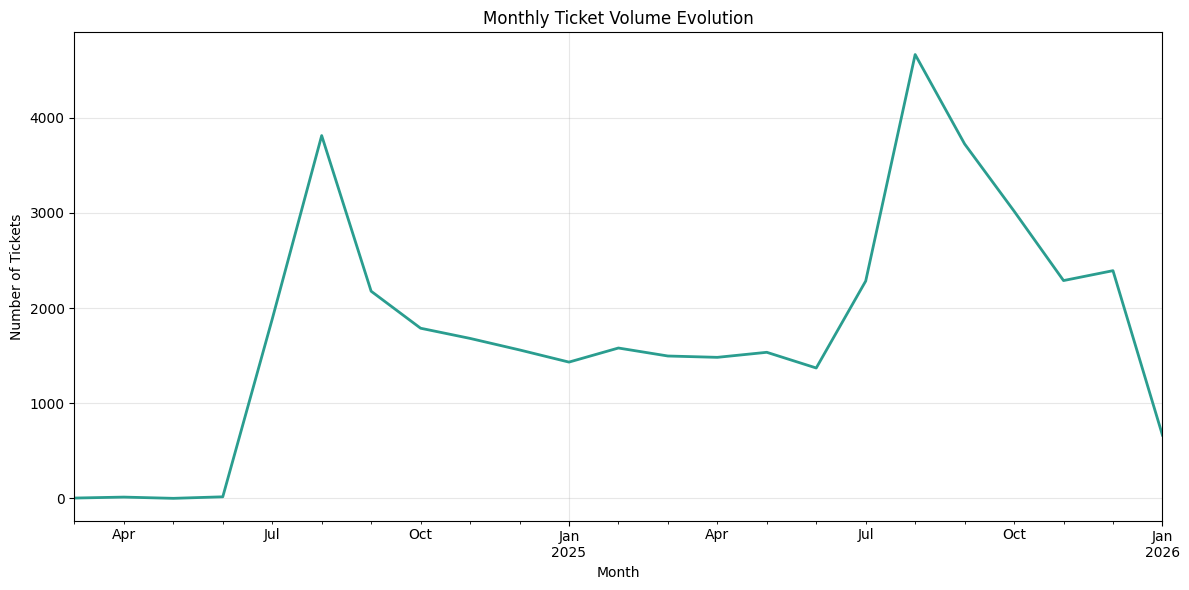

In [35]:
plt.figure(figsize=(12,6))

monthly_tickets.plot(
    linewidth=2,
    color="#2A9D8F"
)

plt.xlabel("Month")
plt.ylabel("Number of Tickets")
plt.title("Monthly Ticket Volume Evolution")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight

The monthly ticket evolution shows clear fluctuations in operational demand over time, including periods of significant growth followed by progressive stabilization.

A strong accumulation of tickets can be observed around mid-2025, particularly during June and July, where ticket creation increased faster than operational resolution capacity.

This pattern coincided with the onboarding of new users into the system following the implementation of a new digital request management platform. The increase in adoption appears to have generated a temporary spike in incoming requests, creating short-term operational pressure.

In the following months, ticket volume gradually stabilized, suggesting an operational recovery and adaptation of the support workflow to the new demand level.

This temporal behavior highlights how operational metrics can reflect organizational and system-level changes beyond day-to-day ticket activity.

#**7. Focus Case: Haberes**

This section presents a focused analysis of the **Haberes** category, which was selected due to its operational relevance and stakeholder interest during the project.

The objective was to better understand ticket behavior within this category, including demand volume, response performance and operational patterns associated with payroll-related requests.

In [36]:
# Filter Haberes tickets

haberes = tickets[
    tickets["CategoriaName"] == "Haberes"
].copy()

haberes.shape

(1805, 154)

In [37]:
# Haberes KPIs

haberes_total = len(haberes)

haberes_closed = haberes["closedat"].notna().sum()

haberes_open = haberes["closedat"].isna().sum()

haberes_resolution_rate = round(
    haberes_closed / haberes_total * 100,
    2
)

haberes_median_resolution = round(
    haberes["resolution_hours"].median(),
    2
)

haberes_kpis = pd.DataFrame({
    "Metric": [
        "Total Haberes Tickets",
        "Closed Tickets",
        "Open Tickets",
        "Resolution Rate (%)",
        "Median Resolution Time (hours)"
    ],
    "Value": [
        haberes_total,
        haberes_closed,
        haberes_open,
        haberes_resolution_rate,
        haberes_median_resolution
    ]
})

haberes_kpis

,Metric,Value
0,Total Haberes Tickets,1805.00
1,Closed Tickets,1728.00
2,Open Tickets,77.00
3,Resolution Rate (%),95.73
4,Median Resolution Time (hours),48.27


In [38]:
# Monthly evolution - Haberes

haberes_monthly = (
    haberes
    .set_index("dt")
    .resample("ME")
    .size()
)

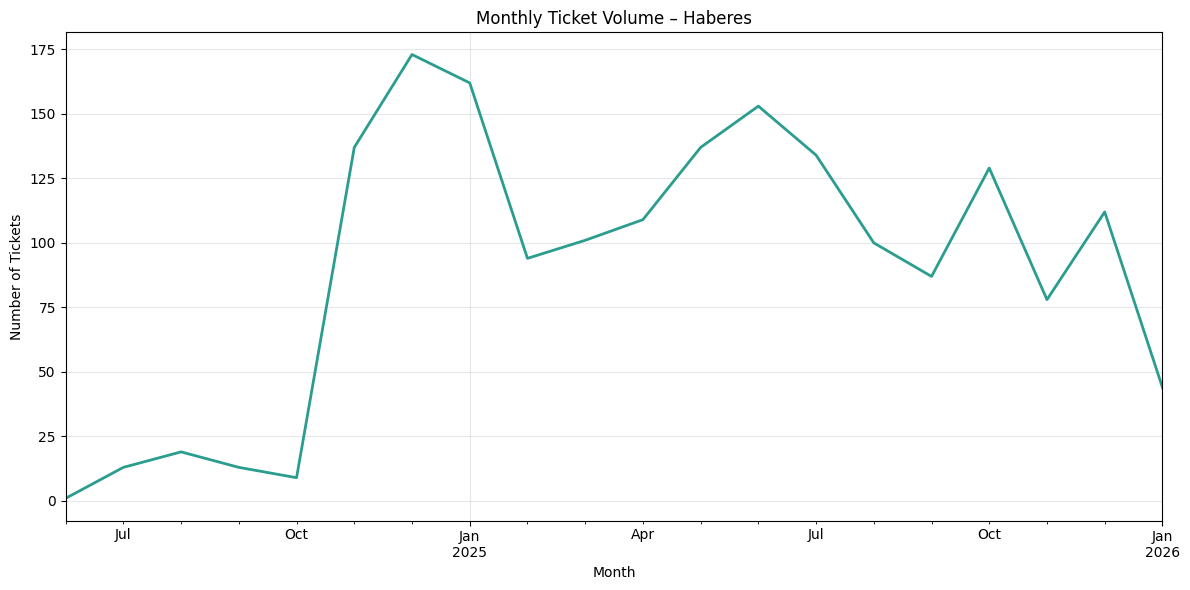

In [39]:
plt.figure(figsize=(12,6))

haberes_monthly.plot(
    linewidth=2,
    color="#2A9D8F"
)

plt.xlabel("Month")
plt.ylabel("Number of Tickets")
plt.title("Monthly Ticket Volume – Haberes")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insight

The **Haberes** category showed consistent operational demand throughout the analyzed period, with a total of 1,805 tickets processed.

Although it represented a smaller share of total ticket volume compared with larger service categories, Haberes remained operationally relevant due to the sustained volume of requests over time.

A key finding was that **median resolution time reached 48.27 hours**, approximately twice the overall system median. This suggests that payroll-related requests involved more complex operational workflows or required additional validation steps before closure.

Despite this longer resolution time, the category maintained a high resolution rate of **95.73%**, indicating strong closure performance over the analyzed period.

The monthly trend also showed relatively stable demand during 2025, reinforcing the importance of Haberes as an ongoing operational service area rather than a temporary peak.

#**8. Focus Case: SUNA & GEN**

This section focuses on selected operational categories that were reviewed separately due to their workflow complexity and stakeholder interest during the project.

Special attention was given to **SUNA** and **GEN**, as these categories showed relevant operational volume and required additional interpretation beyond standard backlog metrics.

In some cases, open tickets did not necessarily indicate unresolved internal workload, but reflected dependency on external actors, third-party providers or ongoing follow-up processes.

In [40]:
# Filter SUNA and GEN related tickets

suna_gen = tickets[
    tickets["CategoriaName"].str.contains(
        "SUNA|GEN",
        case=False,
        na=False
    )
].copy()

suna_gen.shape

(10597, 154)

In [41]:
# SUNA + GEN KPIs

suna_gen_total = len(suna_gen)

suna_gen_closed = suna_gen["closedat"].notna().sum()

suna_gen_open = suna_gen["closedat"].isna().sum()

suna_gen_resolution_rate = round(
    suna_gen_closed / suna_gen_total * 100,
    2
)

suna_gen_median_resolution = round(
    suna_gen["resolution_hours"].median(),
    2
)

suna_gen_kpis = pd.DataFrame({
    "Metric": [
        "Total Tickets",
        "Closed Tickets",
        "Open Tickets",
        "Resolution Rate (%)",
        "Median Resolution Time (hours)"
    ],
    "Value": [
        suna_gen_total,
        suna_gen_closed,
        suna_gen_open,
        suna_gen_resolution_rate,
        suna_gen_median_resolution
    ]
})

suna_gen_kpis

,Metric,Value
0,Total Tickets,10597.00
1,Closed Tickets,9510.00
2,Open Tickets,1087.00
3,Resolution Rate (%),89.74
4,Median Resolution Time (hours),613.98


In [42]:
# Volume by category within SUNA/GEN group

suna_gen_categories = (
    suna_gen["CategoriaName"]
    .value_counts()
    .sort_values(ascending=True)
)

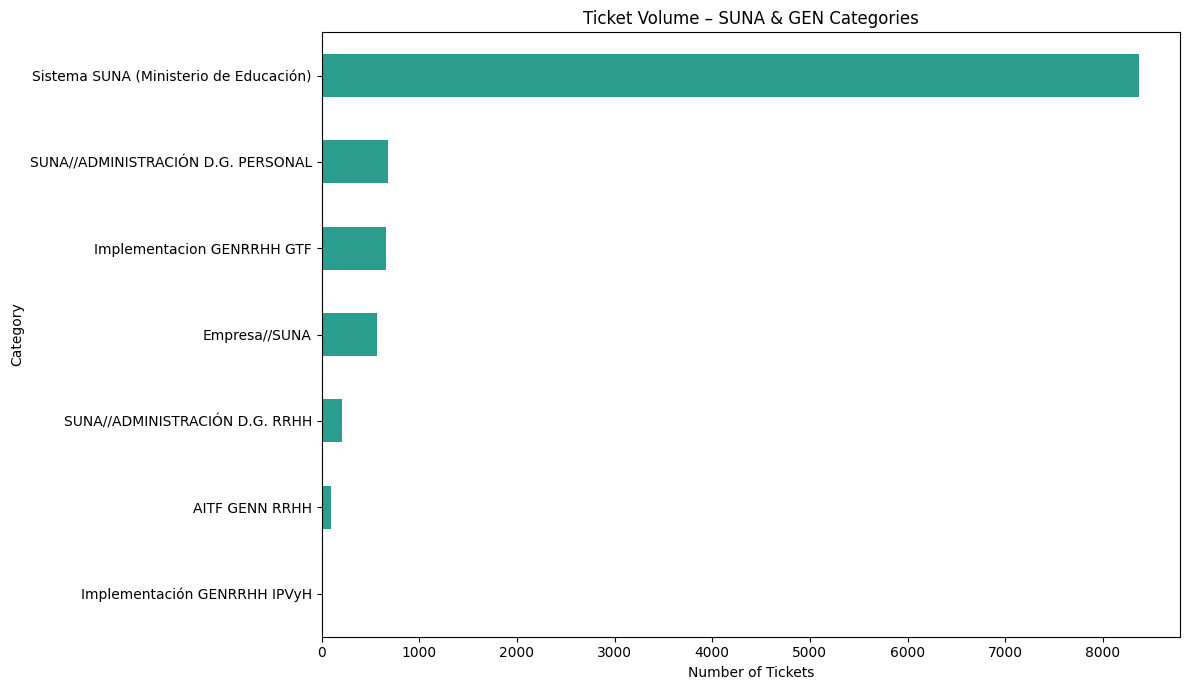

In [43]:
plt.figure(figsize=(12,7))

suna_gen_categories.plot(
    kind="barh",
    color="#2A9D8F"
)

plt.xlabel("Number of Tickets")
plt.ylabel("Category")
plt.title("Ticket Volume – SUNA & GEN Categories")

plt.tight_layout()
plt.show()

### Key Insight

The SUNA and GEN group represented one of the highest operational volumes within the ticket system, with more than 10,000 tickets processed during the analyzed period.

A notable finding was the **median resolution time of 613.98 hours**, significantly higher than the system-wide median. This suggests that these categories followed operational workflows substantially different from the rest of the system.

In these cases, open tickets and extended resolution times did not necessarily indicate unresolved internal workload. Instead, they often reflected:

- dependency on external actors or third-party providers
- long-term follow-up processes
- administrative waiting periods before formal closure

The analysis therefore required contextual interpretation beyond standard backlog metrics.

Within the group, **Sistema SUNA (Ministerio de Educación)** concentrated the majority of ticket volume, confirming its operational relevance within the system and its importance as a key service area during the analysis.

#**9. Key Insights**

The analysis was developed iteratively in collaboration with the stakeholder team, combining exploratory analysis with targeted follow-up requests focused on specific operational categories and workflow behavior.

While the project began as a general operational review of the ticket system, it progressively evolved into a more detailed analysis of service demand, response performance, backlog concentration and category-specific operational dynamics.

The findings below summarize the most relevant insights identified throughout the process.

### Main Findings

**1. High operational volume with strong closure performance**

The system processed more than **40,000 tickets**, maintaining an overall resolution rate above **96%**, which reflects strong operational activity and sustained closure capacity.

---

**2. Ticket demand was concentrated in a small number of categories**

A limited number of service categories generated most of the operational workload, with **Mesa de Ayuda AIF** and **Sistema SUNA** representing the largest share of ticket volume.

---

**3. Operational backlog was unevenly distributed**

Open tickets accumulated mainly in specific categories such as **SUNA/Administración D.G. Personal**, suggesting workload concentration and potential operational bottlenecks in selected service areas.

---

**4. Resolution performance varied significantly across categories**

While the overall system showed a median resolution time close to **24 hours**, categories such as **Haberes** and **SUNA/GEN** showed substantially longer operational cycles, reflecting more complex workflows.

---

**5. Operational metrics reflected broader organizational changes**

The monthly evolution of tickets revealed periods of sudden growth associated with platform implementation and onboarding of new users, followed by progressive operational stabilization.

#**10. Business Recommendations**

Based on the operational findings and the specific requests raised during the collaboration, the following recommendations were identified:


### 1. Prioritize monitoring of backlog-heavy categories

Operational tracking should focus particularly on categories with persistent backlog accumulation, especially those with high open-ticket concentration.

---

### 2. Strengthen monitoring of long-resolution workflows

Categories such as **Haberes** and **SUNA/GEN** would benefit from dedicated monitoring of response and closure times to better understand operational delays and workflow dependencies.

---

### 3. Use category-level KPIs for performance management

Tracking metrics such as:
- ticket volume
- backlog
- first response time
- median resolution time

at category level would improve operational visibility and decision-making.

---

### 4. Combine quantitative metrics with process context

Operational indicators should be interpreted together with workflow knowledge, as open tickets do not always represent unresolved internal workload and may reflect external dependencies or administrative waiting periods.

#**11. Next Steps**

Future development opportunities for this analysis include:

- deeper analysis by assigned agent
- operational segmentation by city or ministry
- SLA monitoring dashboards
- text mining over ticket descriptions and internal notes
- trend detection for recurring operational issues
- automated reporting through dashboard tools such as Power BI or Streamlit

This project demonstrates how operational data can be transformed into actionable insights to support service management, workflow optimization and evidence-based decision-making within public sector organizations.